In [21]:
# from xopr_gline import xopr_utils
import numpy as np
import xarray as xr
import hvplot.xarray
import matplotlib.pyplot as plt
import scipy.constants
from scipy import signal
import pandas as pd
import geopandas as gpd
import xopr.opr_access
import xopr.geometry
import dask
from dask.distributed import LocalCluster
import cartopy.crs as ccrs
import geoviews.feature as gf
import time
import requests
from scipy.optimize import curve_fit

from xopr_gline.xopr_utils import extract_layer_peak_power, surface_bed_reflection_power, get_basal_layer_wgs84
from xopr_gline.empirical import erf_topography_model, get_derivatives

In [22]:
opr = xopr.opr_access.OPRConnection(cache_dir="/tmp")

In [23]:
# Select a segment
selected_collection = "2008_Greenland_TO"
selected_segment = "20080730_01"
print(f"Selected segment: {selected_segment}")

# Query frames
stac_items = opr.query_frames(
    collections=[selected_collection], segment_paths=[selected_segment]
)
print(f"Found {len(stac_items)} frames")
stac_items = stac_items.iloc[-2:]
stac_items

Selected segment: 20080730_01
Found 16 frames


,collection,geometry,properties,assets,bbox,id,links,stac_extensions,stac_version,type
stac_item_id,,,,,,,,,,
Data_20080730_01_015,2008_Greenland_TO,"LINESTRING (-38.00205 66.36023, -37.99053 66.3...",{'datetime': '2008-07-30T12:55:01.699655+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-38.583446381296746, 66.34364557625837, -37.9...",Data_20080730_01_015,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature
Data_20080730_01_016,2008_Greenland_TO,"LINESTRING (-38.58443 66.3647, -38.59894 66.35...",{'datetime': '2008-07-30T13:02:26.973256+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-38.63783591803587, 66.35525551424377, -38.05...",Data_20080730_01_016,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature


In [24]:
# Load the radar data
frames = opr.load_frames(stac_items)
print(f"Loaded {len(frames)} frames")

Loaded 2 frames


In [25]:
# Merge frames into a single flight line
flight_line = xopr.merge_frames(frames)
flight_line

/home/m484s199/xopr-gline/.venv/lib/python3.11/site-packages/xopr/opr_tools.py:57: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  merged_segment = xr.concat(segment_frames, dim='slow_time', combine_attrs=merge_dicts_no_conflicts).sortby('slow_time')


<xarray.Dataset> Size: 48MB
Dimensions:    (slow_time: 2007, twtt: 2001)
Coordinates:
  * slow_time  (slow_time) datetime64[ns] 16kB 2008-07-30T12:51:15.260962725 ...
  * twtt       (twtt) float64 16kB -1.222e-07 -8.883e-08 ... 6.653e-05 6.656e-05
Data variables:
    Time       (slow_time, twtt) float64 32MB -1.222e-07 ... 6.656e-05
    GPS_time   (slow_time) float64 16kB 1.217e+09 1.217e+09 ... 1.217e+09
    Latitude   (slow_time) float64 16kB 66.36 66.36 66.36 ... 66.36 66.36 66.36
    Longitude  (slow_time) float64 16kB -38.0 -38.0 -38.0 ... -38.06 -38.06
    Elevation  (slow_time) float64 16kB 622.4 622.4 622.4 ... 481.7 482.0 482.2
    Roll       (slow_time) float64 16kB 0.1253 0.1284 0.1319 ... 0.05171 0.0557
    Pitch      (slow_time) float64 16kB 0.01973 0.01813 ... 0.0327 0.03337
    Heading    (slow_time) float64 16kB 2.268 2.297 2.327 ... 1.77 1.773 1.776
    Surface    (slow_time) float64 16kB 3.774e-06 3.788e-06 ... 2.812e-06
    Data       (twtt, slow_time) float32 16MB 3.352e-07 3.318e-07 ... 2.345e-27
Attributes: (12/18)
    title:          Radar Echogram Data
    Conventions:    CF-1.8
    param_records:  {'support_path': '/cresis/snfs1/dataproducts/csarp_suppor...
    collection:     2008_Greenland_TO
    segment_path:   20080730_01
    date_str:       20080730
    ...             ...
    comment:        Polar radar echogram data with CF-compliant metadata
    param_combine:  {'array_param': {'Nsv': 1, 'imgs': array([[1, 2],\n      ...
    references:     https://gitlab.com/englacial/xopr
    mimetype:       application/x-matlab-data
    source_url:     {'https://data.cresis.ku.edu/data/rds/2008_Greenland_TO/C...
    granule:        {'20080730_01_016', '20080730_01_015'}

In [26]:
# Load layers for the merged flight line
layers = opr.get_layers(flight_line)
print(f"Available layers: {list(layers.keys())}")

Available layers: ['standard:surface', 'standard:bottom']


In [27]:
for layer_idx in layers:
    layers[layer_idx] = xopr.radar_util.add_along_track(layers[layer_idx])
    layers[layer_idx] = xopr.layer_twtt_to_range(layers[layer_idx], layers["standard:surface"], vertical_coordinate='wgs84')
    layers[layer_idx] = xopr.layer_twtt_to_range(layers[layer_idx], layers["standard:surface"], vertical_coordinate='range')

flight_line = xopr.radar_util.add_along_track(flight_line)
flight_line = xopr.radar_util.interpolate_to_vertical_grid(flight_line, vertical_coordinate='wgs84')

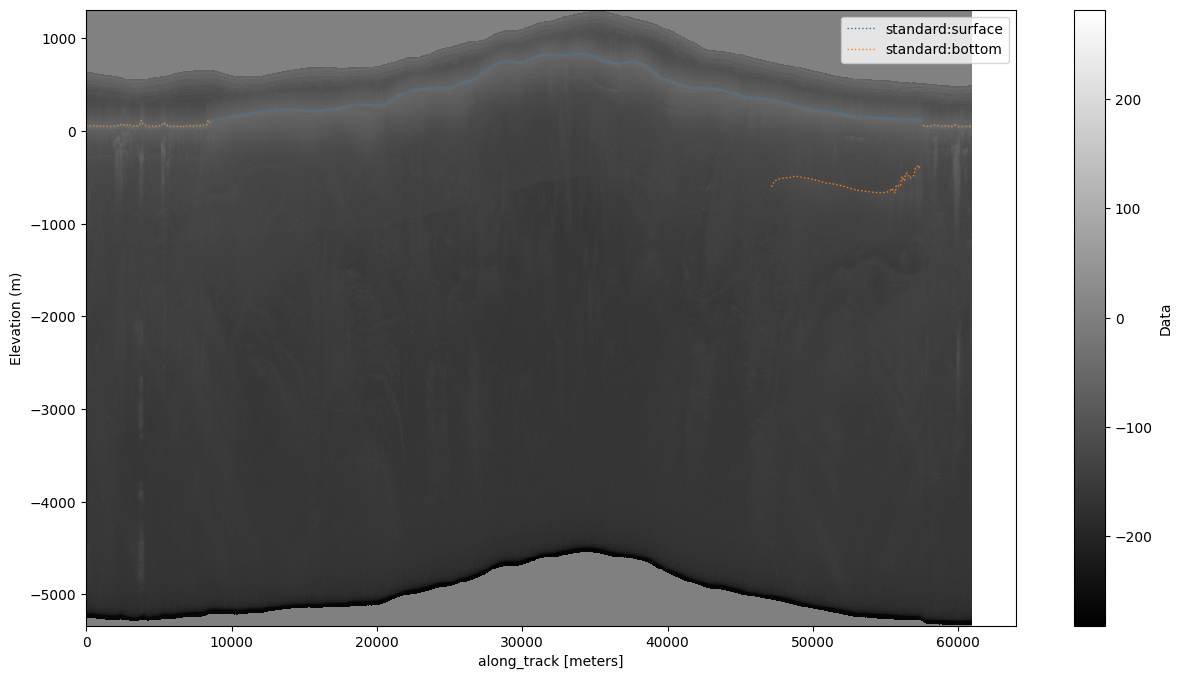

In [28]:
# visualize radargram

clb_min_pct, clb_max_pct  = 30, 97

# Plot radargrams in elevation coordinates with layers
fig, (ax1) = plt.subplots(1, 1, figsize=(15, 8))

# Frame 1 radargram in elevation
pwr_1_elev = 10*np.log10(np.abs(flight_line.Data))
vmax_1 = np.percentile(pwr_1_elev, clb_max_pct)
vmin_1 = np.percentile(pwr_1_elev, clb_min_pct)
pwr_1_elev.plot.imshow(x='along_track', y='wgs84', cmap='gray', ax=ax1)#, vmin=-310, vmax=-240) #-310 -240

# Plot layers using elevation data
for layer_name in layers:
    layers[layer_name]['wgs84'].plot(ax=ax1, x='along_track', linewidth=1, linestyle=':', label=layer_name)

# ax1.set_title(f"{intersect['collection_1']} - {intersect['id_1']} (Elevation view)")
ax1.set_ylabel('Elevation (m)')
ax1.legend()
# ax1.set_xlim(0.3e6, 0.5e6)

In [34]:
def interpolate_points_along_line(geoSeries):
    distances = np.arange(0, geoSeries[0].length, 2)
    line = geoSeries.geometry
    # Filter out distances greater than the line length if necessary
    # valid_distances = distances[distances <= line.length]
    points = [line.interpolate(distance) for distance in distances]
    
    return points

# pts = interpolate_points_along_line(segment_line)
# len(pts)

In [35]:
flight_line = flight_line.assign_coords({"Latitude": flight_line["Latitude"]})
flight_line = flight_line.assign_coords({"Longitude": flight_line["Longitude"]})
flight_line['along_track'].data[-1]

np.float64(60886.65904632596)

In [36]:
flight_line

<xarray.Dataset> Size: 38MB
Dimensions:      (slow_time: 2007, wgs84: 665, twtt: 2001)
Coordinates:
  * slow_time    (slow_time) datetime64[ns] 16kB 2008-07-30T12:51:15.26096272...
  * wgs84        (wgs84) float64 5kB -5.333e+03 -5.323e+03 ... 1.307e+03
  * twtt         (twtt) float64 16kB -1.222e-07 -8.883e-08 ... 6.656e-05
    along_track  (slow_time) float64 16kB 0.0 30.26 ... 6.087e+04 6.089e+04
    Latitude     (slow_time) float64 16kB 66.36 66.36 66.36 ... 66.36 66.36
    Longitude    (slow_time) float64 16kB -38.0 -38.0 -38.0 ... -38.06 -38.06
Data variables:
    Data         (slow_time, wgs84) float32 5MB -1.0 -1.0 -1.0 ... -2.0 -2.0
    Time         (slow_time, twtt) float64 32MB -1.222e-07 ... 6.656e-05
    GPS_time     (slow_time) float64 16kB 1.217e+09 1.217e+09 ... 1.217e+09
    Elevation    (slow_time) float64 16kB 622.4 622.4 622.4 ... 482.0 482.2
    Roll         (slow_time) float64 16kB 0.1253 0.1284 ... 0.05171 0.0557
    Pitch        (slow_time) float64 16kB 0.01973 0.01813 ... 0.0327 0.03337
    Heading      (slow_time) float64 16kB 2.268 2.297 2.327 ... 1.77 1.773 1.776
    Surface      (slow_time) float64 16kB 3.774e-06 3.788e-06 ... 2.812e-06
Attributes: (12/18)
    title:          Radar Echogram Data
    Conventions:    CF-1.8
    param_records:  {'support_path': '/cresis/snfs1/dataproducts/csarp_suppor...
    collection:     2008_Greenland_TO
    segment_path:   20080730_01
    date_str:       20080730
    ...             ...
    comment:        Polar radar echogram data with CF-compliant metadata
    param_combine:  {'array_param': {'Nsv': 1, 'imgs': array([[1, 2],\n      ...
    references:     https://gitlab.com/englacial/xopr
    mimetype:       application/x-matlab-data
    source_url:     {'https://data.cresis.ku.edu/data/rds/2008_Greenland_TO/C...
    granule:        {'20080730_01_016', '20080730_01_015'}

In [37]:
flight_line['Longitude'].to_index().is_monotonic_increasing

False

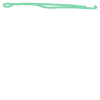

In [38]:
from shapely.geometry import Point, LineString

flight_line_proj = xopr.geometry.project_dataset(flight_line, "EPSG:3413")
xy_points = gpd.points_from_xy(flight_line_proj['x'], flight_line_proj['y'])
lon_lat_points = gpd.points_from_xy(flight_line['Longitude'], flight_line['Latitude'])

flight_line_3413 = LineString(xy_points)
flight_line_4326 = LineString(lon_lat_points)
flight_line_4326

In [39]:
import dask
from dask.distributed import LocalCluster

client = LocalCluster().get_client()

In [40]:
stac_list = [row for _, row in stac_items.iterrows()]
futures = client.map(surface_bed_reflection_power, stac_list, opr=opr)

# Process results as they complete, capturing exceptions
results = []
for future in dask.distributed.as_completed(futures):
    try:
        result = future.result()
        results.append(result)
    except Exception as e:
        print(traceback.format_exc())

/home/m484s199/xopr-gline/src/xopr_gline/xopr_utils.py:73: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'slow_time' ('slow_time',) The recommendation is to set join explicitly for this case.
  reflectivity_dataset = xr.merge([
/home/m484s199/xopr-gline/src/xopr_gline/xopr_utils.py:81: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'slow_time' ('slow_time',) The recommendation is to set join explicitly for this case.
  reflectivity_dataset = xr.merge([reflectivity_dataset, flight_line_metadata])
/home/m484s199/xop

In [42]:
results[1]

<xarray.Dataset> Size: 8kB
Dimensions:           (slow_time: 93)
Coordinates:
  * slow_time         (slow_time) datetime64[ns] 744B 2008-07-30T12:51:15 ......
Data variables:
    surface_twtt      (slow_time) float64 744B 3.812e-06 3.779e-06 ... 2.312e-06
    bed_twtt          (slow_time) float64 744B 3.812e-06 3.779e-06 ... nan nan
    surface_power_dB  (slow_time) float32 372B -39.64 -40.39 ... -39.32 -37.93
    bed_power_dB      (slow_time) float32 372B -39.64 -40.39 -37.87 ... nan nan
    GPS_time          (slow_time) float64 744B 1.217e+09 1.217e+09 ... 1.217e+09
    Latitude          (slow_time) float64 744B 66.36 66.36 66.36 ... 66.37 66.37
    Longitude         (slow_time) float64 744B -38.0 -37.99 ... -38.58 -38.58
    Elevation         (slow_time) float64 744B 621.9 617.0 ... 1.092e+03
    Roll              (slow_time) float64 744B 0.1372 0.1203 ... 0.04651 0.03364
    Pitch             (slow_time) float64 744B 0.008876 -0.001048 ... 0.1366
    Heading           (slow_time) float64 744B 2.43 2.794 ... -2.601 -2.571
Attributes:
    segment:  1

In [43]:
reflectivity_concat = xr.concat(results, dim="slow_time").sortby("slow_time")
reflectivity_concat

<xarray.Dataset> Size: 15kB
Dimensions:           (slow_time: 174)
Coordinates:
  * slow_time         (slow_time) datetime64[ns] 1kB 2008-07-30T12:51:15 ... ...
Data variables:
    surface_twtt      (slow_time) float64 1kB 3.812e-06 3.779e-06 ... 2.878e-06
    bed_twtt          (slow_time) float64 1kB 3.812e-06 3.779e-06 ... 2.878e-06
    surface_power_dB  (slow_time) float32 696B -39.64 -40.39 ... -38.62 -40.07
    bed_power_dB      (slow_time) float32 696B -39.64 -40.39 ... -38.62 -40.07
    GPS_time          (slow_time) float64 1kB 1.217e+09 1.217e+09 ... 1.217e+09
    Latitude          (slow_time) float64 1kB 66.36 66.36 66.36 ... 66.36 66.36
    Longitude         (slow_time) float64 1kB -38.0 -37.99 ... -38.07 -38.06
    Elevation         (slow_time) float64 1kB 621.9 617.0 608.5 ... 475.6 480.3
    Roll              (slow_time) float64 1kB 0.1372 0.1203 ... 0.02392 0.04389
    Pitch             (slow_time) float64 1kB 0.008876 -0.001048 ... 0.03084
    Heading           (slow_time) float64 1kB 2.43 2.794 0.05074 ... 1.715 1.762
Attributes:
    segment:  1

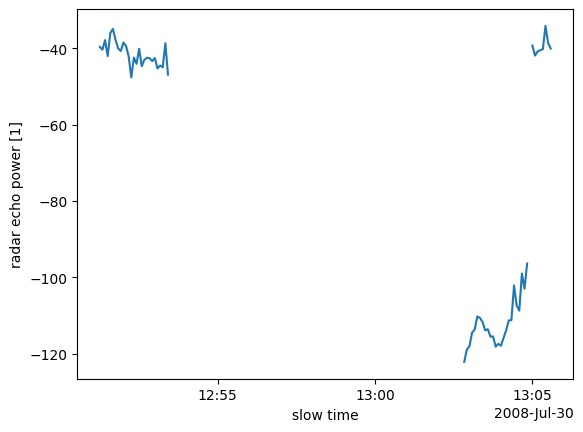

In [44]:
reflectivity_concat['bed_power_dB'].plot()

In [45]:
reflectivity_concat = xopr.radar_util.add_along_track(reflectivity_concat)

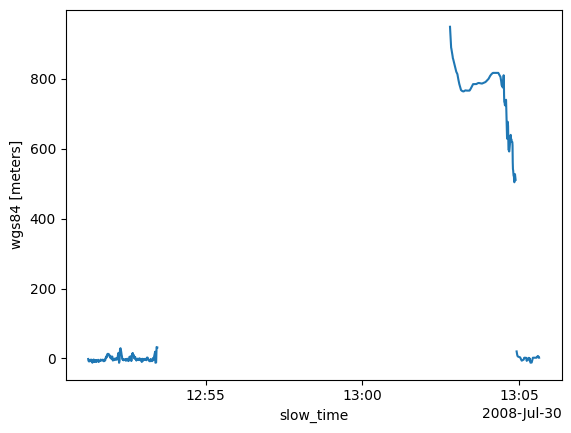

In [122]:
# Get thickness
H = layers['standard:surface']['wgs84'] - layers['standard:bottom']['wgs84']
# Get a thickness mask so max gradient is over glacier and not melange or other noise
H_mask = H > 50
H.plot()

In [126]:
H_filt = H[H_mask]
thick_slow_time_min = H_filt.slow_time.min()
thick_slow_time_max = H_filt.slow_time.max()

In [104]:
bed_power_grad = np.gradient(reflectivity_concat['bed_power_dB']) # the Xia paper takes the second derivative but that looks worse
reflectivity_concat['bed_power_grad'] = (('slow_time'), bed_power_grad)

# get the index of the peak bed power and grab the bed elevation index too
grad_max_idx = reflectivity_concat['bed_power_grad'].argmax(dim="slow_time").data
grad_max = reflectivity_concat['bed_power_grad'].max()

grad_slowtime = reflectivity_concat['bed_power_grad']['slow_time'][grad_max_idx]
bed_point = layers['standard:bottom']['wgs84'].sel(slow_time=grad_slowtime.data, method='nearest')
bed_point.along_track

<xarray.DataArray 'along_track' ()> Size: 8B
array(57534.75297094)
Coordinates:
    slow_time    datetime64[ns] 8B 2008-07-30T13:04:54.930455923
    along_track  float64 8B 5.753e+04
Attributes:
    units:        meters
    description:  Cumulative distance along the radar track

In [155]:
bed_power_grad = np.gradient(reflectivity_concat['bed_power_dB']) # the Xia paper takes the second derivative but that looks worse
reflectivity_concat['bed_power_grad'] = (('slow_time'), bed_power_grad)
bed_power_grad_filter = reflectivity_concat['bed_power_grad'].sel(slow_time=slice(thick_slow_time_min, thick_slow_time_max) )

# get the index of the peak bed power and grab the bed elevation index too
grad_max_idx = bed_power_grad_filter.argmax(dim="slow_time").data
grad_max = bed_power_grad_filter.max()

grad_slowtime = bed_power_grad_filter['slow_time'][grad_max_idx]
bed_point = layers['standard:bottom']['wgs84'].sel(slow_time=grad_slowtime.data, method='nearest')
bed_point

<xarray.DataArray 'wgs84' ()> Size: 8B
array(-665.3583772)
Coordinates:
    slow_time    datetime64[ns] 8B 2008-07-30T13:04:19.841129065
    along_track  float64 8B 5.477e+04
Attributes:
    units:        meters
    description:  WGS84 elevation of layer

In [139]:
reflectivity_concat['bed_power_grad'].sel(slow_time=slice(thick_slow_time_min, thick_slow_time_max) )

<xarray.DataArray 'bed_power_grad' (slow_time: 25)> Size: 100B
array([        nan,  2.0517426 ,  2.224041  ,  2.1932983 ,  2.1154099 ,
        1.5126572 , -0.7366638 , -1.6238518 , -0.94112015, -0.8212471 ,
       -0.9385185 , -1.3149261 , -0.9658623 ,  0.12076569,  0.7424278 ,
        2.0381584 ,  2.3167648 ,  1.3080635 ,  4.56723   ,  1.9237442 ,
       -3.2927399 ,  4.1860313 ,  2.8765335 ,  1.3082619 ,         nan],
      dtype=float32)
Coordinates:
  * slow_time    (slow_time) datetime64[ns] 200B 2008-07-30T13:02:50 ... 2008...
    along_track  (slow_time) float64 200B 4.761e+04 4.802e+04 ... 5.744e+04

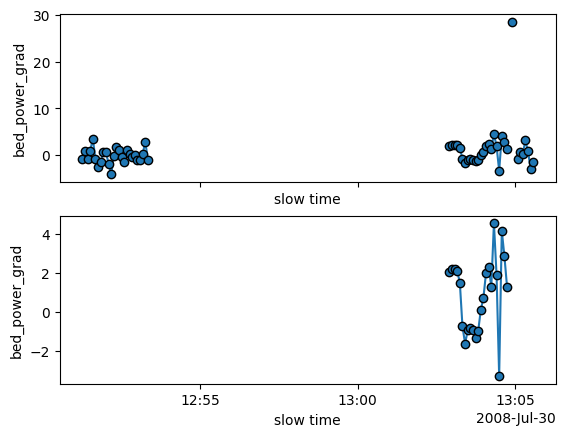

In [153]:
fig_test, (ax_test1, ax_test2) = plt.subplots(2,1, sharex=True)
reflectivity_concat['bed_power_grad'].plot(ax=ax_test1, linestyle='-',marker='o', mec='k')
bed_power_grad_filter.plot(ax=ax_test2, linestyle='-',marker='o', mec='k')
# ax_test.scatter(grad_slowtime, grad_max)

In [156]:
bed_point

<xarray.DataArray 'wgs84' ()> Size: 8B
array(-665.3583772)
Coordinates:
    slow_time    datetime64[ns] 8B 2008-07-30T13:04:19.841129065
    along_track  float64 8B 5.477e+04
Attributes:
    units:        meters
    description:  WGS84 elevation of layer

In [142]:
reflectivity_concat['bed_power_grad'].data[grad_max_idx]

np.float32(0.2026329)

In [159]:
# layers['standard:bottom']['wgs84'].slow_time.max()
bed_point.along_track

<xarray.DataArray 'along_track' ()> Size: 8B
array(54771.51878652)
Coordinates:
    slow_time    datetime64[ns] 8B 2008-07-30T13:04:19.841129065
    along_track  float64 8B 5.477e+04
Attributes:
    units:        meters
    description:  Cumulative distance along the radar track

In [144]:
# grad_slowtime.data
layers['standard:bottom']['wgs84'].sel(slow_time=grad_slowtime.data,method='nearest')

<xarray.DataArray 'wgs84' ()> Size: 8B
array(-665.3583772)
Coordinates:
    slow_time    datetime64[ns] 8B 2008-07-30T13:04:19.841129065
    along_track  float64 8B 5.477e+04
Attributes:
    units:        meters
    description:  WGS84 elevation of layer

Text(0.5, 1.0, 'Bed power gradient')

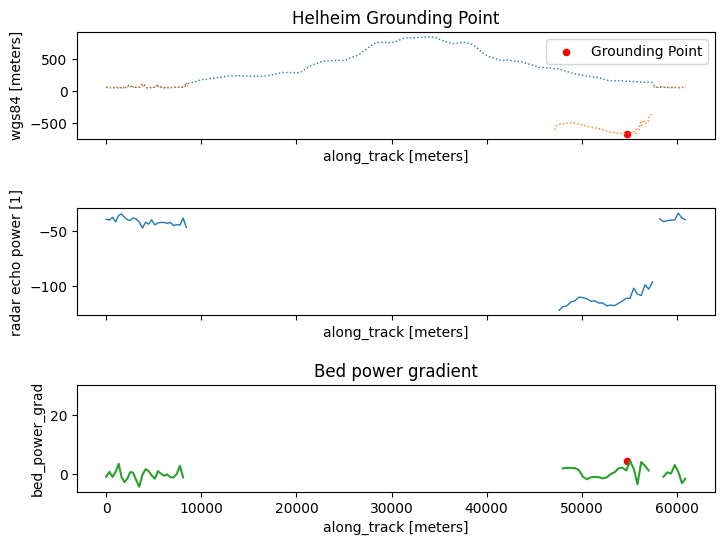

In [161]:
# Plot layers using elevation data and slow_time
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(8,6), sharex=True)
fig.tight_layout(pad=4.0)

for layer_name in layers:
    layers[layer_name]['wgs84'].plot(ax=ax1, x='along_track', linewidth=1, linestyle=':')#, label=layer_name)

ax1.scatter(bed_point.along_track, bed_point, color='r', s=20, label="Grounding Point")
ax1.set_title('Helheim Grounding Point')

# ax1.axvspan(along_track_lat1.data, along_track_lat2.data, color='tab:green',
#             alpha=0.5, label='2011-2015 gz')


reflectivity_concat['bed_power_dB'].plot(ax=ax2, x='along_track', linewidth=1)
# for result in results:
#     result = xopr.radar_util.add_along_track(result)
#     result['bed_power_dB'].plot(ax=ax2, x='along_track', label='Bed Power dB', color='tab:green')
# ax3.scatter(grad_slowtime, grad_max, color='r', s=20, label="Grounding Point")


# Plot layers using elevation data
#ax3 plot
reflectivity_concat['bed_power_grad'].plot(ax=ax3, x='along_track', label='bed_grad', color='tab:green')
ax3.scatter(bed_point.along_track, grad_max, color='r', s=20, label="Grounding Point")

ax1.legend()
# ax3.legend()
ax3.set_title('Bed power gradient')
# fig.savefig('/home/m484s199/gline_figures/petermann_20100420_merged_frame.png', dpi=300)

In [146]:
reflectivity_concat['along_track'][grad_max_idx]

<xarray.DataArray 'along_track' ()> Size: 8B
array(5775.07629849)
Coordinates:
    slow_time    datetime64[ns] 8B 2008-07-30T12:52:45
    along_track  float64 8B 5.775e+03
Attributes:
    units:        meters
    description:  Cumulative distance along the radar track

In [70]:
grad_max

<xarray.DataArray 'bed_power_grad' ()> Size: 4B
array(28.537712, dtype=float32)

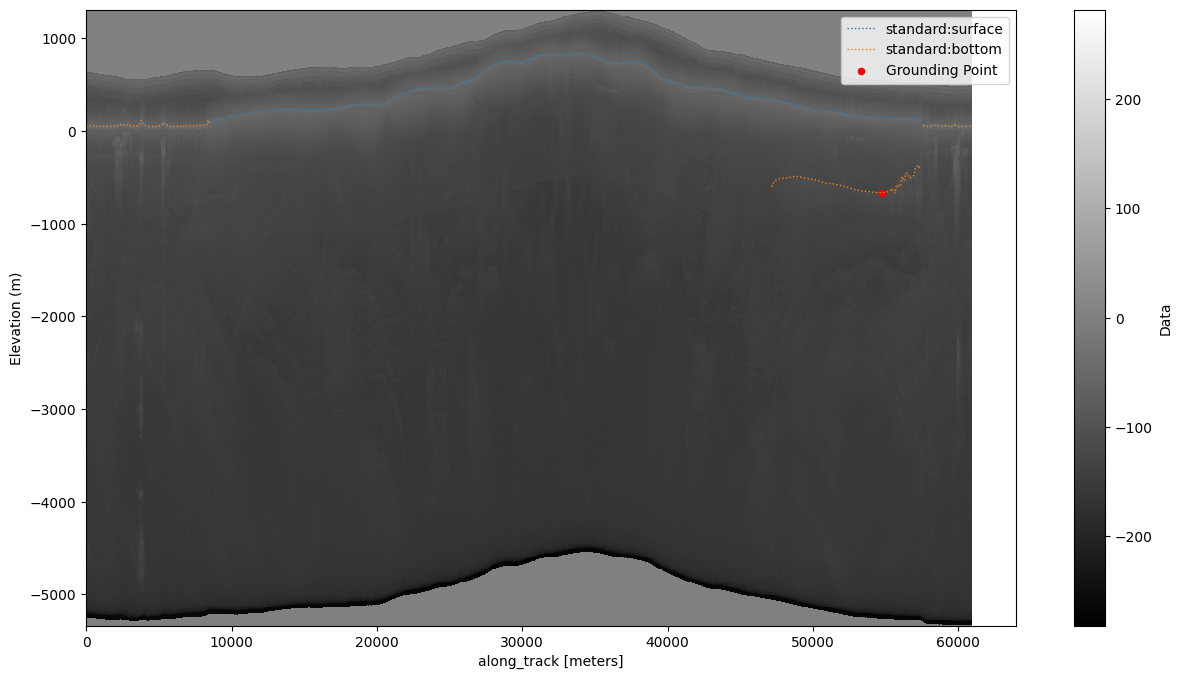

In [163]:
# visualize radargram

clb_min_pct, clb_max_pct  = 30, 97

# Plot radargrams in elevation coordinates with layers
fig, (ax1) = plt.subplots(1, 1, figsize=(15, 8))

# Frame 1 radargram in elevation
pwr_1_elev = 10*np.log10(np.abs(flight_line.Data))
vmax_1 = np.percentile(pwr_1_elev, clb_max_pct)
vmin_1 = np.percentile(pwr_1_elev, clb_min_pct)
pwr_1_elev.plot.imshow(x='along_track', y='wgs84', cmap='gray', ax=ax1)#, vmin=-310, vmax=-240) #-310 -240

# Plot layers using elevation data
for layer_name in layers:
    layers[layer_name]['wgs84'].plot(ax=ax1, x='along_track', linewidth=1, linestyle=':', label=layer_name)

# Plot Grounding Point
ax1.scatter(bed_point.along_track, bed_point, color='r', s=20, label="Grounding Point")


# ax1.set_title(f"{intersect['collection_1']} - {intersect['id_1']} (Elevation view)")
ax1.set_ylabel('Elevation (m)')
ax1.legend()
# ax1.set_xlim(0.3e6, 0.5e6)
fig.savefig('/home/m484s199/grounding_point_figs/helheim_grounding_point_20080730.png', dpi=300)